# Smart Warehouse Outbound Delay Prediction
## 전체 파이프라인 (Clean Version)

### 주요 EDA 발견사항
- **Target skewness 5.68** → log1p 변환 확정
- **결측치 ~12% 균일 분포** → MCAR 패턴 (센서 독립적 결측)
- **shift_hour 0~23, 시나리오 내 랜덤 배치** → lag feature 불가
- **shift_hour 후반(18~23시) delay 급증** → temporal degradation 패턴
- **Target bimodal 분포** → 정상 운영 구간 vs 병목 발생 구간

### 모델 탐색 결과
| 모델 | num_leaves | RMSE |
|------|-----------|------|
| model3 | 127 | 19.37 |
| model4 | 127, lr=0.02 | 19.41 |
| **model5** | **255** | **19.31 ✅** |
| model6 | 511 | 19.33 |

## 0. 라이브러리 & 데이터 로드

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import lightgbm as lgb
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

os.makedirs('./models', exist_ok=True)

train = pd.read_csv('./data/train.csv')
test  = pd.read_csv('./data/test.csv')
layout = pd.read_csv('./data/layout_info.csv')

print(f'train: {train.shape}, test: {test.shape}, layout: {layout.shape}')

train: (250000, 94), test: (50000, 93), layout: (300, 15)


## 1. 전처리 - Scenario-level Aggregation

In [2]:
# Scenario-level 통계 (train 기준으로 생성 → test에 매핑)
agg_features = train.groupby('scenario_id').agg(
    sc_battery_mean_avg   = ('battery_mean', 'mean'),
    sc_low_battery_max    = ('low_battery_ratio', 'max'),
    sc_congestion_avg     = ('congestion_score', 'mean'),
    sc_order_inflow_avg   = ('order_inflow_15m', 'mean'),
    sc_order_inflow_max   = ('order_inflow_15m', 'max'),
    sc_robot_charging_avg = ('robot_charging', 'mean'),
).reset_index()

# Layout merge (building_age_years 제외 - 불필요 컬럼)
layout_clean = layout[['layout_id', 'layout_type', 'aisle_width_avg',
                        'intersection_count', 'one_way_ratio', 'pack_station_count',
                        'charger_count', 'layout_compactness', 'zone_dispersion',
                        'robot_total', 'floor_area_sqm', 'ceiling_height_m',
                        'fire_sprinkler_count', 'emergency_exit_count']]

# Train merge
train = train.merge(agg_features, on='scenario_id', how='left')
train = train.merge(layout_clean, on='layout_id', how='left')

# Test merge
test = test.merge(agg_features, on='scenario_id', how='left')
test = test.merge(layout_clean, on='layout_id', how='left')

print(f'train: {train.shape}, test: {test.shape}')
print('중복 컬럼:', [c for c in train.columns if '_x' in c or '_y' in c])

train: (250000, 113), test: (50000, 112)
중복 컬럼: []


## 2. 전처리 - 결측치 처리

In [3]:
TARGET = 'avg_delay_minutes_next_30m'

# 수치형 컬럼 분리
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_no_target = [c for c in numeric_cols if c != TARGET]
numeric_cols_test = test.select_dtypes(include=[np.number]).columns.tolist()

# 결측 indicator 생성 (결측 자체가 정보)
missing_cols = [col for col in numeric_cols_no_target if train[col].isnull().any()]
for col in missing_cols:
    train[f'{col}_missing'] = train[col].isnull().astype(int)
    test[f'{col}_missing']  = test[col].isnull().astype(int)

print(f'결측 indicator 추가: {len(missing_cols)}개')

# Median imputation (train fit → test transform, leakage 방지)
imputer = SimpleImputer(strategy='median')
train[numeric_cols_no_target] = imputer.fit_transform(train[numeric_cols_no_target])
test[numeric_cols_test]       = imputer.transform(test[numeric_cols_test])

print(f'결측치 잔여 - train: {train.isnull().sum().sum()}, test: {test.isnull().sum().sum()}')
print(f'train: {train.shape}, test: {test.shape}')

결측 indicator 추가: 86개
결측치 잔여 - train: 0, test: 0
train: (250000, 199), test: (50000, 198)


## 3. Feature Engineering

In [4]:
def add_features(df):
    new_feats = pd.DataFrame(index=df.index)
    
    # Battery-Robot 상호작용
    new_feats['battery_robot_stress']  = df['low_battery_ratio'] * df['robot_charging']
    new_feats['charge_pressure']       = df['charge_queue_length'] / (df['robot_idle'] + 1)
    new_feats['effective_robot_ratio'] = df['robot_active'] / (df['robot_active'] + df['robot_charging'] + 1)
    
    # 주문-용량 압박
    new_feats['order_robot_ratio'] = df['order_inflow_15m'] / (df['robot_active'] + 1)
    new_feats['order_complexity']  = df['order_inflow_15m'] * df['avg_items_per_order']
    new_feats['urgent_pressure']   = df['urgent_order_ratio'] * df['order_inflow_15m']
    
    # Layout 연계
    new_feats['robots_per_area']     = df['robot_total'] / df['floor_area_sqm']
    new_feats['charger_sufficiency'] = df['charger_count'] / df['robot_total']
    new_feats['pack_capacity_ratio'] = df['pack_utilization'] / (df['pack_station_count'] + 1)
    
    # Shift hour 주기성
    new_feats['shift_hour_sin']  = np.sin(2 * np.pi * df['shift_hour'] / 24)
    new_feats['shift_hour_cos']  = np.cos(2 * np.pi * df['shift_hour'] / 24)
    new_feats['late_shift_flag'] = (df['shift_hour'] >= 18).astype(int)
    
    return pd.concat([df, new_feats], axis=1).copy()

train = add_features(train)
test  = add_features(test)

print(f'train: {train.shape}, test: {test.shape}')

train: (250000, 211), test: (50000, 210)


## 4. 인코딩 & 불필요 컬럼 제거

In [5]:
# layout_type 인코딩
le = LabelEncoder()
train['layout_type'] = le.fit_transform(train['layout_type'])
test['layout_type']  = le.transform(test['layout_type'])

# ID, layout_id, scenario_id 제거
drop_cols = ['ID', 'layout_id', 'scenario_id']
train = train.drop(columns=drop_cols)
test  = test.drop(columns=drop_cols)

print(f'train: {train.shape}, test: {test.shape}')
print('object 컬럼 잔여:', train.select_dtypes(include='object').columns.tolist())

train: (250000, 208), test: (50000, 207)
object 컬럼 잔여: []


## 5. 모델 학습 (Best: model5, num_leaves=255)

In [6]:
X = train.drop(columns=[TARGET])
y = np.log1p(train[TARGET])  # log1p 변환 (skewness 5.68)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'X_train: {X_train.shape}, X_val: {X_val.shape}')

X_train: (200000, 207), X_val: (50000, 207)


In [7]:
model5 = lgb.LGBMRegressor(
    n_estimators     = 5000,
    learning_rate    = 0.05,
    num_leaves       = 255,
    max_depth        = -1,
    min_child_samples= 20,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 0.1,
    random_state     = 42,
    n_jobs           = -1
)

model5.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(500)]
)

joblib.dump(model5, './models/lgbm_model5.pkl')

y_pred = model5.predict(X_val)
rmse_log  = np.sqrt(mean_squared_error(y_val, y_pred))
rmse_orig = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(y_pred)))
print(f'Validation RMSE (log scale):      {rmse_log:.4f}')
print(f'Validation RMSE (original scale): {rmse_orig:.4f}')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.061196 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25075
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 207
[LightGBM] [Info] Start training from score 2.423409
Training until validation scores don't improve for 100 rounds
[500]	valid_0's l2: 0.269282
[1000]	valid_0's l2: 0.257182
[1500]	valid_0's l2: 0.252865
[2000]	valid_0's l2: 0.251049
[2500]	valid_0's l2: 0.249995
[3000]	valid_0's l2: 0.249308
[3500]	valid_0's l2: 0.24895
[4000]	valid_0's l2: 0.248742
[4500]	valid_0's l2: 0.248647
[5000]	valid_0's l2: 0.248563
Did not meet early stopping. Best iteration is:
[4988]	valid_0's l2: 0.248561
Validation RMSE (log scale):      0.4986
Validation RMSE (original scale): 19.4142


## 6. Feature Importance

                       feature  importance
11           avg_trip_distance       14714
2          avg_items_per_order       14556
60        pick_list_length_avg       14194
70       charge_efficiency_pct       14162
13                battery_mean       13998
90         sc_battery_mean_avg       13806
54          conveyor_speed_mps       13777
37             air_quality_idx       13761
83          quality_check_rate       13690
62            bulk_order_ratio       13685
39               hvac_power_kw       13667
35         floor_vibration_idx       13664
28                humidity_pct       13660
67  maintenance_schedule_score       13651
65        pallet_wrap_time_min       13618
63           staging_area_util       13609
47   barcode_read_success_rate       13567
45        safety_score_monthly       13523
76     path_optimization_score       13510
78         storage_density_pct       13501


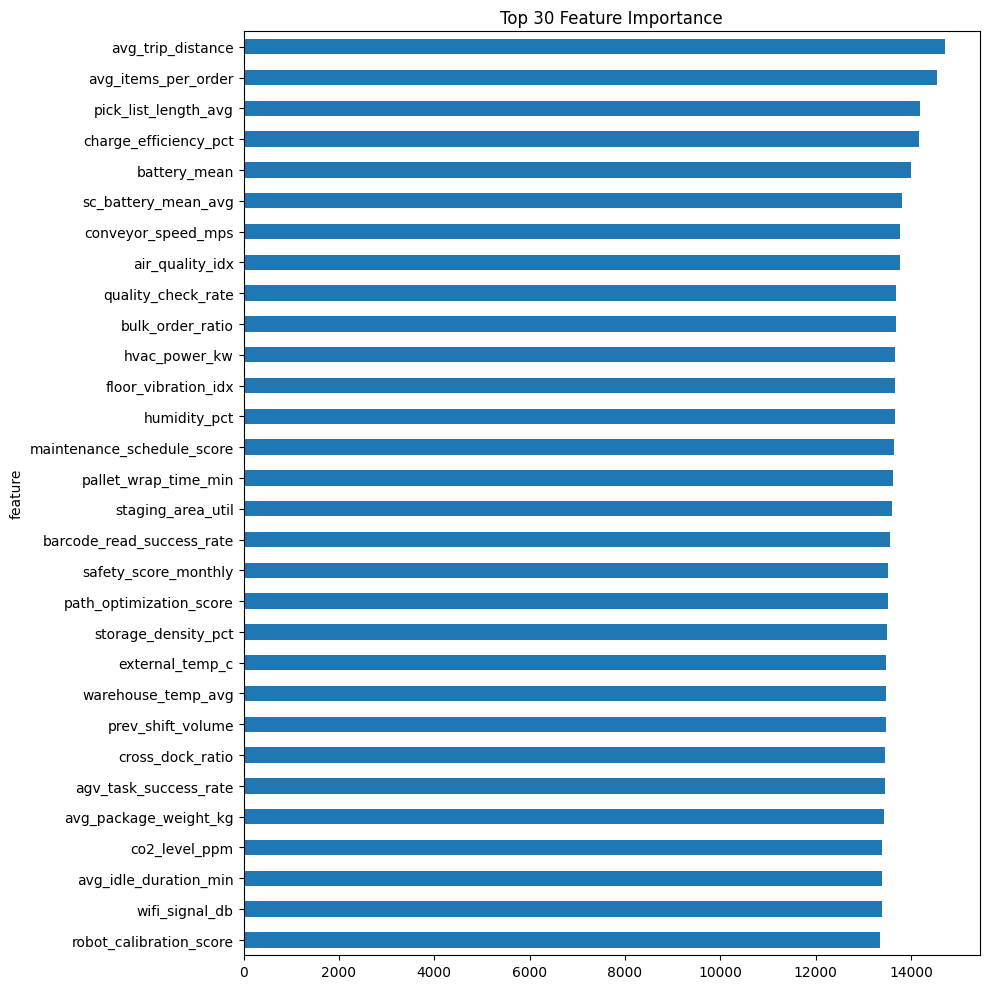

In [8]:
importance = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': model5.feature_importances_
}).sort_values('importance', ascending=False)

print(importance.head(20).to_string())

importance.head(30).plot(kind='barh', x='feature', y='importance',
                          figsize=(10, 10), legend=False)
plt.title('Top 30 Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Submission 생성

In [9]:
test_id = pd.read_csv('./data/test.csv')['ID']

y_test_pred      = model5.predict(test)
y_test_pred_orig = np.expm1(y_test_pred)

submission = pd.DataFrame({
    'ID'                        : test_id,
    'avg_delay_minutes_next_30m': y_test_pred_orig
})

submission.to_csv('./results/submission_model5.csv', index=False)
print(submission.shape)
print(submission.head())

(50000, 2)
            ID  avg_delay_minutes_next_30m
0  TEST_000000                   10.468607
1  TEST_000001                   10.590988
2  TEST_000002                   10.066276
3  TEST_000003                   10.167427
4  TEST_000004                   12.663739
